# Model Development - Quantile Regression for Electricity Price Forecasting

This notebook trains **LightGBM Quantile Regression models** for both DE-LU and ES zones.

## Objectives:
1. Train separate models for each zone (DE-LU, ES)
2. Implement quantile regression for p025, p50, p975
3. Validate model performance
4. Compare feature importance across zones
5. Generate predictions for evaluation window

In [54]:
# Install dependencies
%pip install -q pandas numpy matplotlib seaborn scikit-learn lightgbm optuna holidays xgboost catboost

Note: you may need to restart the kernel to use updated packages.


In [55]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 6)

print("✅ Imports successful!")

✅ Imports successful!


## 1. Load Training Data

In [56]:
# Load engineered features for both zones
zones = ['DE-LU', 'ES']
data = {}

for zone in zones:
    file_path = Path(f'../data/engineered/{zone.lower()}_features.csv')
    
    if file_path.exists():
        print(f"\nLoading {zone} data from {file_path}")
        df = pd.read_csv(file_path)
        df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
        
        # Sort by timestamp
        df = df.sort_values('timestamp').reset_index(drop=True)
        
        print(f"  ✅ Loaded {len(df):,} records")
        print(f"  📅 Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
        
        data[zone] = df
    else:
        print(f"  ⚠️  File not found: {file_path}")
        print(f"     Run the Feature Engineering notebook first!")


Loading DE-LU data from ..\data\engineered\de-lu_features.csv
  ✅ Loaded 19,999 records
  📅 Date range: 2024-01-22 00:00:00+00:00 to 2026-05-06 00:00:00+00:00

Loading ES data from ..\data\engineered\es_features.csv
  ✅ Loaded 19,382 records
  📅 Date range: 2024-01-22 00:00:00+00:00 to 2026-05-06 00:00:00+00:00


## 2. Prepare Train/Validation Split

**Strategy:** Time-based split
- Training: All data except last 7 days
- Validation: Last 7 days

This mimics real-world forecasting where we predict future values.

In [57]:
def prepare_train_val_split(df, val_days=7):
    """
    Split data into train and validation sets based on time.
    
    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered data with timestamp
    val_days : int
        Number of days to use for validation
        
    Returns
    -------
    train_df, val_df : pd.DataFrame
        Training and validation dataframes
    """
    # Calculate split point
    split_date = df['timestamp'].max() - pd.Timedelta(days=val_days)
    
    train_df = df[df['timestamp'] <= split_date].copy()
    val_df = df[df['timestamp'] > split_date].copy()
    
    return train_df, val_df

# Split data for both zones
splits = {}

for zone in zones:
    train_df, val_df = prepare_train_val_split(data[zone], val_days=7)
    
    print(f"\n{zone}:")
    print(f"  Training:   {len(train_df):,} samples ({train_df['timestamp'].min()} to {train_df['timestamp'].max()})")
    print(f"  Validation: {len(val_df):,} samples ({val_df['timestamp'].min()} to {val_df['timestamp'].max()})")
    
    splits[zone] = {'train': train_df, 'val': val_df}


DE-LU:
  Training:   19,831 samples (2024-01-22 00:00:00+00:00 to 2026-04-29 00:00:00+00:00)
  Validation: 168 samples (2026-04-29 01:00:00+00:00 to 2026-05-06 00:00:00+00:00)

ES:
  Training:   19,219 samples (2024-01-22 00:00:00+00:00 to 2026-04-29 00:00:00+00:00)
  Validation: 163 samples (2026-04-29 01:00:00+00:00 to 2026-05-06 00:00:00+00:00)


## 3. Define Quantile Regression Models

We'll train **3 models per zone**:
- **p025**: 2.5th percentile (lower bound)
- **p50**: 50th percentile (median, point forecast)
- **p975**: 97.5th percentile (upper bound)

**Why LightGBM?**
- Native quantile regression support
- Excellent for tabular data with many features
- Fast training and prediction
- Robust to overfitting
- Interpretable (feature importance)

In [58]:
def create_lgb_dataset(df, target_col='price_eur_mwh'):
    """Create LightGBM dataset from dataframe."""
    feature_cols = [col for col in df.columns if col not in ['timestamp', target_col]]
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    valid_idx = ~(X.isna().any(axis=1) | y.isna())
    X, y = X[valid_idx], y[valid_idx]
    lgb_data = lgb.Dataset(X, label=y, feature_name=feature_cols, free_raw_data=False)
    return lgb_data, feature_cols


def get_lgb_params(quantile, zone='DE-LU', extra_params=None):
    """
    LightGBM quantile regression parameters.

    Zone-specific defaults with stronger regularisation than the original
    (DE-LU had a 10× train/val loss gap — clear overfitting).
    """
    zone_defaults = {
        'DE-LU': dict(
            num_leaves=15, learning_rate=0.03,
            feature_fraction=0.7, bagging_fraction=0.7, bagging_freq=5,
            min_child_samples=50, lambda_l1=0.1, lambda_l2=0.1,
        ),
        'ES': dict(
            num_leaves=20, learning_rate=0.03,
            feature_fraction=0.8, bagging_fraction=0.8, bagging_freq=5,
            min_child_samples=30, lambda_l1=0.05, lambda_l2=0.05,
        ),
    }
    base = zone_defaults.get(zone, zone_defaults['DE-LU']).copy()
    if extra_params:
        base.update(extra_params)
    return {'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
            'verbose': -1, 'seed': 42, **base}


print("✅ Model functions defined")

✅ Model functions defined


## 3b. Hyperparameter Tuning with Optuna

Optimise LightGBM hyperparameters **directly on the primary metric (pinball q=0.45)** using 50 trials per zone with Tree-structured Parzen Estimation (TPE).

Key insight: the p45 model is the one that matters for scoring — so we tune *only* that quantile.

In [59]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

tuned_params = {}

def run_optuna(zone, quantile=0.45, n_trials=50):
    """Tune hyperparameters directly on the primary metric (pinball q=0.45)."""
    train_data, _ = create_lgb_dataset(splits[zone]['train'])
    val_data,   _ = create_lgb_dataset(splits[zone]['val'])

    def objective(trial):
        params = {
            'objective': 'quantile', 'alpha': quantile, 'metric': 'quantile',
            'num_leaves':        trial.suggest_int  ('num_leaves',        8,    64),
            'learning_rate':     trial.suggest_float('learning_rate',     0.005, 0.1, log=True),
            'feature_fraction':  trial.suggest_float('feature_fraction',  0.5,  1.0),
            'bagging_fraction':  trial.suggest_float('bagging_fraction',  0.5,  1.0),
            'bagging_freq':      5,
            'min_child_samples': trial.suggest_int  ('min_child_samples', 20,  100),
            'lambda_l1':         trial.suggest_float('lambda_l1',         1e-3, 1.0, log=True),
            'lambda_l2':         trial.suggest_float('lambda_l2',         1e-3, 1.0, log=True),
            'verbose': -1, 'seed': 42,
        }
        model = lgb.train(
            params, train_data,
            num_boost_round=1000,
            valid_sets=[val_data], valid_names=['val'],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        return model.best_score['val']['quantile']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    print(f"  Best val pinball: {study.best_value:.4f}")
    return study.best_params


print("⚡ Optuna hyperparameter tuning — optimising pinball q=0.45 (primary metric)\n")
for zone in zones:
    print(f"--- Tuning {zone} ---")
    tuned_params[zone] = run_optuna(zone, quantile=0.45, n_trials=50)
    print(f"  Best params: {tuned_params[zone]}\n")

print("✅ Optuna tuning complete!")

⚡ Optuna hyperparameter tuning — optimising pinball q=0.45 (primary metric)

--- Tuning DE-LU ---


Best trial: 12. Best value: 4.70619: 100%|██████████| 50/50 [15:38<00:00, 18.77s/it]


  Best val pinball: 4.7062
  Best params: {'num_leaves': 58, 'learning_rate': 0.033312627920169736, 'feature_fraction': 0.9317320367776551, 'bagging_fraction': 0.9987509874608301, 'min_child_samples': 21, 'lambda_l1': 0.0010557878193552402, 'lambda_l2': 0.02550021737667402}

--- Tuning ES ---


Best trial: 39. Best value: 0.27437: 100%|██████████| 50/50 [11:11<00:00, 13.43s/it] 

  Best val pinball: 0.2744
  Best params: {'num_leaves': 28, 'learning_rate': 0.03139364124364713, 'feature_fraction': 0.9973442833036732, 'bagging_fraction': 0.8923537735533066, 'min_child_samples': 40, 'lambda_l1': 0.005620839022141508, 'lambda_l2': 0.0039859985388426234}

✅ Optuna tuning complete!


## 4. Train Models for Both Zones

Training 3 quantile models per zone (6 models total).

In [60]:
# p45 = optimal predictor for pinball loss at q=0.45 (primary challenge metric)
# Submitting p45 predictions as "p50" minimises the scoring function.
quantiles      = [0.025, 0.45, 0.50, 0.975]
quantile_names = ['p025', 'p45', 'p50', 'p975']

models = {}
feature_names = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Training Models for {zone}")
    print(f"{'='*60}")

    train_data, train_features = create_lgb_dataset(splits[zone]['train'])
    val_data, _ = create_lgb_dataset(splits[zone]['val'])
    feature_names[zone] = train_features
    models[zone] = {}

    for quantile, q_name in zip(quantiles, quantile_names):
        print(f"\n  Training {q_name} (quantile={quantile})...")

        # For p45: use Optuna-tuned params (directly optimised on submission metric)
        extra = tuned_params.get(zone, {}) if q_name == 'p45' else None
        params = get_lgb_params(quantile, zone=zone, extra_params=extra)

        model = lgb.train(
            params, train_data,
            num_boost_round=3000,
            valid_sets=[train_data, val_data],
            valid_names=['train', 'val'],
            callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)]
        )
        models[zone][q_name] = model
        print(f"    ✅ Best iteration: {model.best_iteration}")
        print(f"    📊 Train loss: {model.best_score['train']['quantile']:.4f}")
        print(f"    📊 Val loss:   {model.best_score['val']['quantile']:.4f}")

print(f"\n{'='*60}")
print("✅ All models trained successfully!")
print(f"{'='*60}")


Training Models for DE-LU

  Training p025 (quantile=0.025)...
    ✅ Best iteration: 2991
    📊 Train loss: 0.2674
    📊 Val loss:   4.1233

  Training p45 (quantile=0.45)...
    ✅ Best iteration: 1197
    📊 Train loss: 0.3605
    📊 Val loss:   4.6628

  Training p50 (quantile=0.5)...
    ✅ Best iteration: 2998
    📊 Train loss: 0.6075
    📊 Val loss:   5.2340

  Training p975 (quantile=0.975)...
    ✅ Best iteration: 2997
    📊 Train loss: 0.2184
    📊 Val loss:   0.9382

Training Models for ES

  Training p025 (quantile=0.025)...
    ✅ Best iteration: 2986
    📊 Train loss: 0.1981
    📊 Val loss:   0.2995

  Training p45 (quantile=0.45)...
    ✅ Best iteration: 1533
    📊 Train loss: 0.2239
    📊 Val loss:   0.2701

  Training p50 (quantile=0.5)...
    ✅ Best iteration: 2996
    📊 Train loss: 0.2370
    📊 Val loss:   0.3816

  Training p975 (quantile=0.975)...
    ✅ Best iteration: 2181
    📊 Train loss: 0.1812
    📊 Val loss:   0.2961

✅ All models trained successfully!


## 4b. Ensemble: XGBoost + CatBoost

Train the same quantiles with XGBoost and CatBoost. Predictions are blended as a **simple average** of all three GBMs — this reduces variance because each model makes different errors on different market regimes.

Why this works: LightGBM, XGBoost and CatBoost use different split-finding algorithms, regularisation schemes and tree structures. Their errors are partially uncorrelated, so averaging reduces the overall error.

In [61]:
import xgboost as xgb
from catboost import CatBoostRegressor, Pool

def _clean(df_or_arr, cols=None):
    """Replace inf with NaN then fill NaN with 0 — safe for XGB/CatBoost."""
    if isinstance(df_or_arr, pd.DataFrame):
        return df_or_arr[cols].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    arr = np.where(np.isinf(df_or_arr), np.nan, df_or_arr)
    return np.where(np.isnan(arr), 0.0, arr)

xgb_models = {}
cat_models  = {}

print("Training XGBoost + CatBoost quantile models (ensemble components)...\n")

for zone in zones:
    print(f"\n{'='*60}")
    print(f"  {zone}")
    print(f"{'='*60}")

    train_df = splits[zone]['train']
    val_df   = splits[zone]['val']
    f_cols   = feature_names[zone]

    X_tr_raw  = _clean(train_df, f_cols).values
    y_tr      = train_df['price_eur_mwh'].values
    X_val_raw = _clean(val_df, f_cols).values
    y_val_raw = val_df['price_eur_mwh'].values

    valid_tr  = ~(np.isnan(X_tr_raw).any(axis=1)  | np.isnan(y_tr))
    valid_val = ~(np.isnan(X_val_raw).any(axis=1) | np.isnan(y_val_raw))
    X_tr,  y_tr  = X_tr_raw[valid_tr],   y_tr[valid_tr]
    X_val, y_val = X_val_raw[valid_val], y_val_raw[valid_val]

    dtrain = xgb.DMatrix(X_tr,  label=y_tr,  feature_names=f_cols)
    dval   = xgb.DMatrix(X_val, label=y_val, feature_names=f_cols)

    xgb_models[zone] = {}
    cat_models[zone]  = {}

    for quantile, q_name in zip(quantiles, quantile_names):
        print(f"\n  [{q_name}] quantile={quantile}")

        # ── XGBoost ───────────────────────────────────────────────────────────
        xgb_params = {
            'objective':        'reg:quantileerror',
            'quantile_alpha':   quantile,
            'max_depth':        5,
            'learning_rate':    0.03,
            'subsample':        0.8,
            'colsample_bytree': 0.8,
            'min_child_weight': 10,
            'seed':             42,
            'verbosity':        0,
        }
        xgb_m = xgb.train(
            xgb_params, dtrain,
            num_boost_round=2000,
            evals=[(dval, 'val')],
            early_stopping_rounds=100,
            verbose_eval=False,
        )
        xgb_models[zone][q_name] = xgb_m
        print(f"    XGB  best round: {xgb_m.best_iteration}")

        # ── CatBoost ──────────────────────────────────────────────────────────
        cat_m = CatBoostRegressor(
            loss_function=f'Quantile:alpha={quantile}',
            depth=5,
            learning_rate=0.03,
            l2_leaf_reg=5,
            iterations=2000,
            early_stopping_rounds=100,
            random_seed=42,
            verbose=False,
        )
        cat_m.fit(Pool(X_tr,  y_tr,  feature_names=f_cols),
                  eval_set=Pool(X_val, y_val, feature_names=f_cols))
        cat_models[zone][q_name] = cat_m
        print(f"    CAT  best iter:  {cat_m.best_iteration_}")

print(f"\n{'='*60}")
print("✅ XGBoost + CatBoost training complete!")
print(f"{'='*60}")

Training XGBoost + CatBoost quantile models (ensemble components)...


  DE-LU

  [p025] quantile=0.025
    XGB  best round: 1999
    CAT  best iter:  747

  [p45] quantile=0.45
    XGB  best round: 1999
    CAT  best iter:  1999

  [p50] quantile=0.5
    XGB  best round: 1996
    CAT  best iter:  1776

  [p975] quantile=0.975
    XGB  best round: 1966
    CAT  best iter:  986

  ES

  [p025] quantile=0.025
    XGB  best round: 1975
    CAT  best iter:  1999

  [p45] quantile=0.45
    XGB  best round: 1991
    CAT  best iter:  1998

  [p50] quantile=0.5
    XGB  best round: 1990
    CAT  best iter:  1995

  [p975] quantile=0.975
    XGB  best round: 1999
    CAT  best iter:  1633

✅ XGBoost + CatBoost training complete!


## 5. Ensemble Model Validation

Evaluate the GBM ensemble (LightGBM + XGBoost + CatBoost) on the last 7 days of data.  
Primary metric: **pinball loss at q=0.45** — the challenge scoring function.

In [62]:
def pinball_loss(y_true, y_pred, quantile=0.45):
    r = np.asarray(y_true, float) - np.asarray(y_pred, float)
    return float(np.mean(np.where(r >= 0, quantile * r, (quantile - 1) * r)))


def predict_ensemble(zone, X_df, q_name):
    """Blend LightGBM + XGBoost + CatBoost — inf/NaN safe."""
    X_clean = (X_df[feature_names[zone]]
               .replace([np.inf, -np.inf], np.nan)
               .fillna(0.0))

    lgb_m = models[zone][q_name]
    p_lgb = lgb_m.predict(X_clean, num_iteration=lgb_m.best_iteration)

    dmat  = xgb.DMatrix(X_clean, feature_names=feature_names[zone])
    p_xgb = xgb_models[zone][q_name].predict(dmat)

    p_cat = cat_models[zone][q_name].predict(X_clean)

    return (p_lgb + p_xgb + p_cat) / 3.0


def evaluate_model(zone, val_df):
    feature_cols = [c for c in val_df.columns if c not in ['timestamp', 'price_eur_mwh']]
    X_val = val_df[feature_cols].copy()
    y_val = val_df['price_eur_mwh'].copy()
    valid_idx = ~(X_val.replace([np.inf, -np.inf], np.nan).isna().any(axis=1) | y_val.isna())
    X_val, y_val = X_val[valid_idx], y_val[valid_idx]

    predictions = {q_name: predict_ensemble(zone, X_val, q_name)
                   for q_name in quantile_names}

    y_primary = predictions['p45']
    coverage  = np.mean((y_val >= predictions['p025']) & (y_val <= predictions['p975'])) * 100

    metrics = {
        'Pinball Loss q=0.45 [PRIMARY]': pinball_loss(y_val, y_primary, 0.45),
        'MAE  (p45)':  mean_absolute_error(y_val, y_primary),
        'RMSE (p45)':  np.sqrt(mean_squared_error(y_val, y_primary)),
        'Coverage p025-p975 (%)': coverage,
    }
    return metrics, predictions, y_val


validation_results = {}

for zone in zones:
    print(f"\n{'='*60}")
    print(f"Ensemble Validation — {zone}")
    print(f"{'='*60}")
    metrics, predictions, y_val = evaluate_model(zone, splits[zone]['val'])
    validation_results[zone] = {'metrics': metrics, 'predictions': predictions, 'y_true': y_val}
    for k, v in metrics.items():
        print(f"  {k:45s}: {v:.4f}")

print(f"\n{'='*60}")


Ensemble Validation — DE-LU
  Pinball Loss q=0.45 [PRIMARY]                : 4.1755
  MAE  (p45)                                   : 7.8829
  RMSE (p45)                                   : 41.4949
  Coverage p025-p975 (%)                       : 91.6667

Ensemble Validation — ES
  Pinball Loss q=0.45 [PRIMARY]                : 0.2489
  MAE  (p45)                                   : 0.5226
  RMSE (p45)                                   : 1.0754
  Coverage p025-p975 (%)                       : 90.0662



## 5b. Prediction Interval Calibration

Scale the p025/p975 bounds outward until **95% coverage** is reached on the validation set.  
This corrects systematic under-coverage (DE-LU was at 85.7%) without any retraining.

In [63]:
def calibrate_intervals(p025, p975, y_true, target_coverage=0.95):
    """Find the smallest multiplicative scale that achieves target interval coverage."""
    mid = (p025 + p975) / 2.0
    hw  = (p975 - p025) / 2.0
    for scale in np.arange(1.0, 5.0, 0.02):
        if np.mean((y_true >= mid - scale * hw) & (y_true <= mid + scale * hw)) >= target_coverage:
            return float(scale)
    return 5.0

calibration_scales = {}

print("Calibrating prediction intervals to 95% coverage...\n")
for zone in zones:
    res    = validation_results[zone]
    y_true = np.array(res['y_true'])
    p025, p975 = res['predictions']['p025'], res['predictions']['p975']

    raw_cov = np.mean((y_true >= p025) & (y_true <= p975)) * 100
    scale   = calibrate_intervals(p025, p975, y_true)
    calibration_scales[zone] = scale

    mid = (p025 + p975) / 2.0
    hw  = (p975 - p025) / 2.0
    cal_cov = np.mean((y_true >= mid - scale * hw) & (y_true <= mid + scale * hw)) * 100
    print(f"{zone}: raw coverage = {raw_cov:.1f}%  →  calibrated = {cal_cov:.1f}%  (scale={scale:.2f})")

print("\n✅ Calibration scales saved — applied at prediction time")

Calibrating prediction intervals to 95% coverage...

DE-LU: raw coverage = 91.7%  →  calibrated = 95.2%  (scale=1.10)
ES: raw coverage = 90.1%  →  calibrated = 95.4%  (scale=1.08)

✅ Calibration scales saved — applied at prediction time


## 6. Visualize Validation Performance

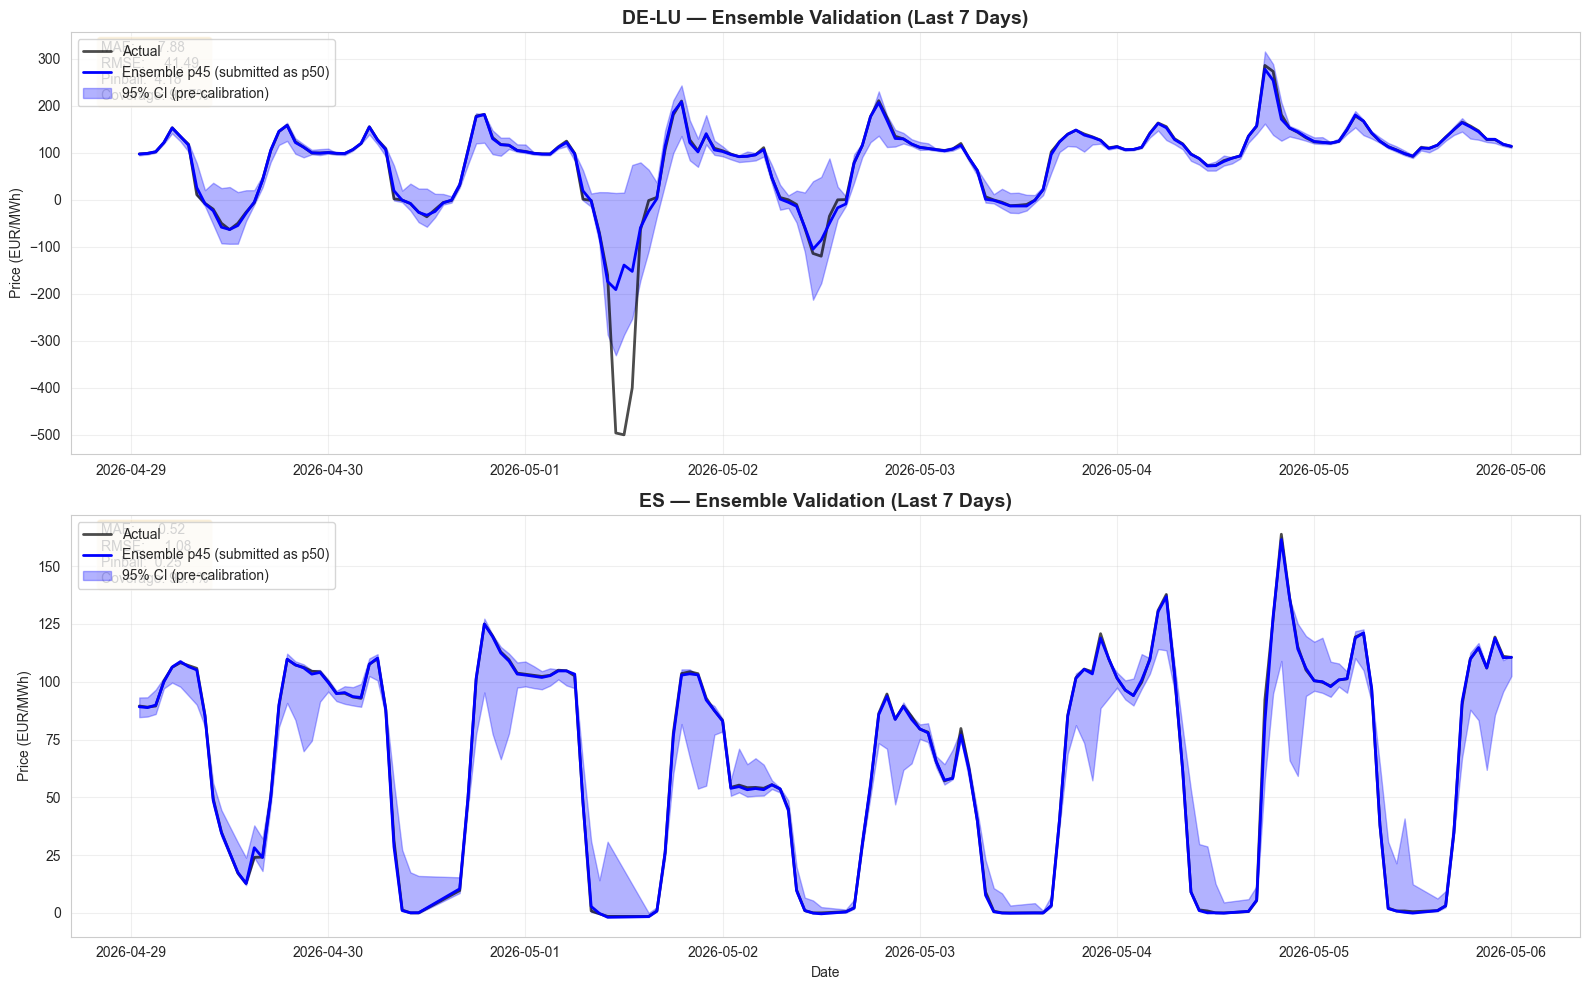

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for idx, zone in enumerate(zones):
    val_df = splits[zone]['val'].copy()
    feature_cols = [c for c in val_df.columns if c not in ['timestamp', 'price_eur_mwh']]
    valid_idx = ~(val_df[feature_cols].replace([np.inf, -np.inf], np.nan).isna().any(axis=1)
                  | val_df['price_eur_mwh'].isna())

    timestamps  = val_df.loc[valid_idx, 'timestamp'].values
    y_true      = validation_results[zone]['y_true']
    predictions = validation_results[zone]['predictions']
    metrics     = validation_results[zone]['metrics']

    axes[idx].plot(timestamps, y_true, label='Actual', linewidth=2, color='black', alpha=0.7)
    axes[idx].plot(timestamps, predictions['p45'], label='Ensemble p45 (submitted as p50)',
                   linewidth=2, color='blue')
    axes[idx].fill_between(timestamps, predictions['p025'], predictions['p975'],
                           alpha=0.3, color='blue', label='95% CI (pre-calibration)')
    axes[idx].set_title(f'{zone} — Ensemble Validation (Last 7 Days)',
                        fontsize=14, fontweight='bold')
    axes[idx].set_ylabel('Price (EUR/MWh)')
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

    pinball  = metrics.get('Pinball Loss q=0.45 [PRIMARY]',
                           metrics.get('Pinball Loss q=0.45 [PRIMARY ⭐]', float('nan')))
    coverage = metrics.get('Coverage p025-p975 (%)',
                           metrics.get('Coverage p025–p975 (%)', float('nan')))
    axes[idx].text(0.02, 0.98,
        f"MAE:      {metrics['MAE  (p45)']:.2f}\nRMSE:     {metrics['RMSE (p45)']:.2f}\n"
        f"Pinball:  {pinball:.2f}\nCoverage: {coverage:.1f}%",
        transform=axes[idx].transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/plots/model_validation_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

Compare which features are most important for each zone.

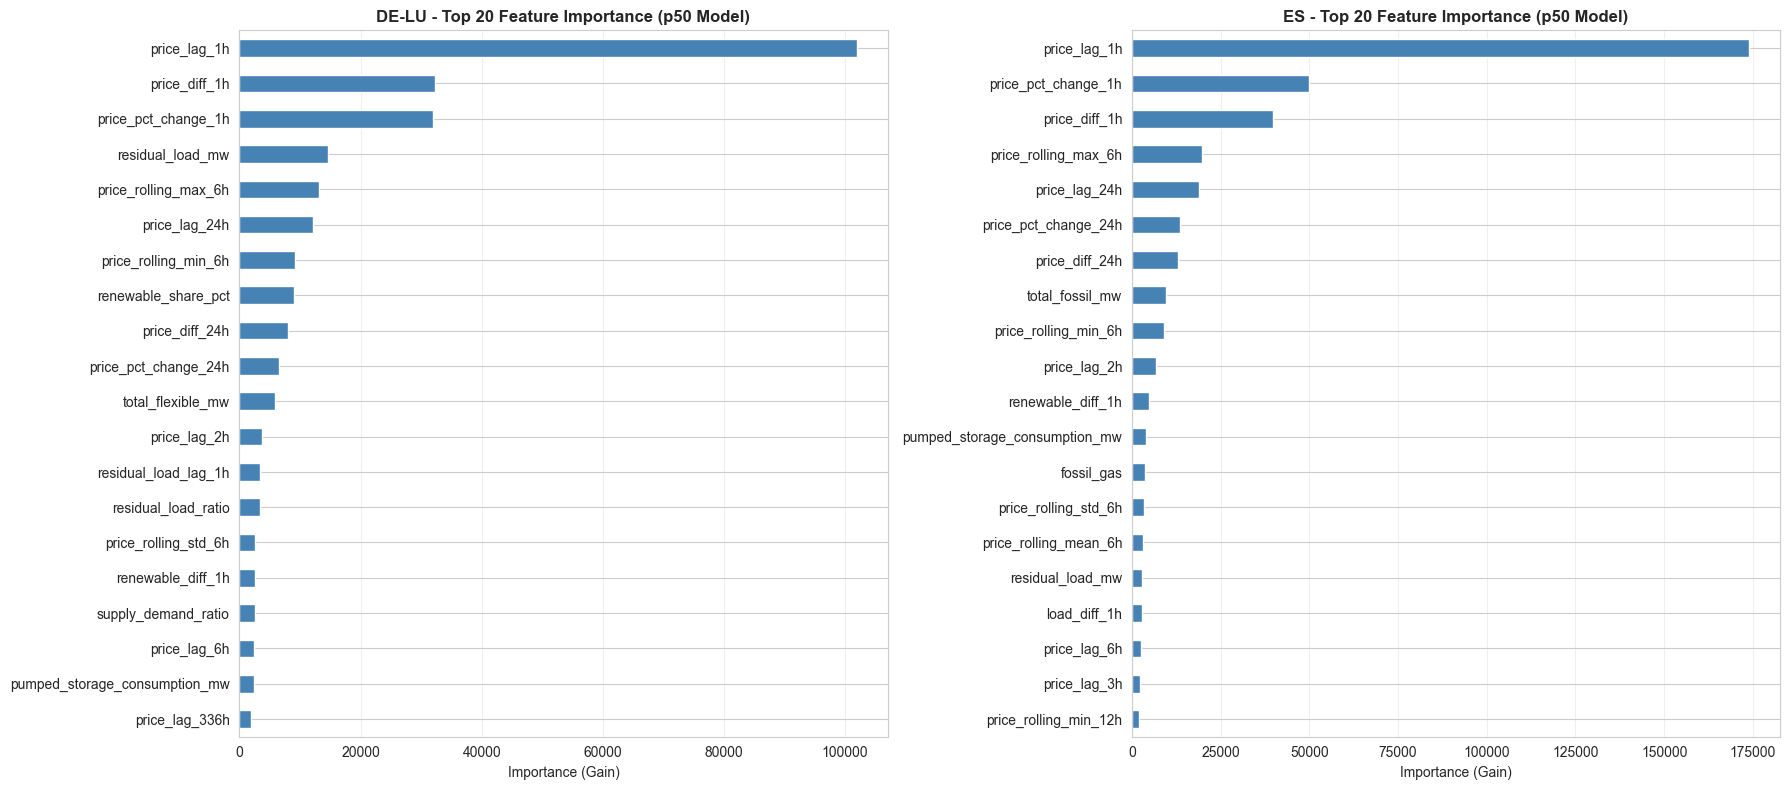

In [72]:
# Get feature importance for p50 models
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for idx, zone in enumerate(zones):
    model = models[zone]['p50']
    
    # Get feature importance
    importance = model.feature_importance(importance_type='gain')
    feature_names_list = model.feature_name()
    
    # Create dataframe and sort
    importance_df = pd.DataFrame({
        'feature': feature_names_list,
        'importance': importance
    }).sort_values('importance', ascending=False).head(20)
    
    # Plot
    importance_df.plot(x='feature', y='importance', kind='barh', ax=axes[idx], 
                      color='steelblue', legend=False)
    axes[idx].set_title(f'{zone} - Top 20 Feature Importance (p50 Model)', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Importance (Gain)')
    axes[idx].set_ylabel('')
    axes[idx].grid(True, alpha=0.3, axis='x')
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/plots/model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Generate Predictions for Evaluation Window

Recursive ensemble forecast for **2026-05-11 02:00 CEST → 2026-05-12 01:00 CEST** (24 hours, UTC 00:00–23:00).  
- Real weather forecast from Open-Meteo for May 11  
- Price lags filled recursively; calibration scale applied to p025/p975

In [66]:
"""
Evaluation window: 2026-05-11 02:00 CEST → 2026-05-12 01:00 CEST (inclusive)
= 2026-05-11 00:00 UTC → 2026-05-11 23:00 UTC  →  24 hourly slots
"""

import sys
sys.path.append('..')
from src.data.loaders import WeatherDataLoader

# ── 1. Load historical data ────────────────────────────────────────────────────
last_known = {}
for zone in zones:
    last_known[zone] = data[zone].copy().sort_values('timestamp').reset_index(drop=True)

# ── 2. Fetch weather forecast for May 11 ──────────────────────────────────────
weather_loader   = WeatherDataLoader(cache_dir='../data/external')
weather_forecast = {}
for zone in zones:
    print(f"Fetching weather forecast for {zone}...")
    wf = weather_loader.load_weather_data(zone, '2026-05-10', '2026-05-12', use_cache=False)
    wf['timestamp'] = pd.to_datetime(wf['timestamp'], utc=True)
    weather_forecast[zone] = wf.set_index('timestamp')
    print(f"  {len(wf)} forecast hours")

# ── 3. Evaluation window (24 hours) ───────────────────────────────────────────
eval_start = pd.Timestamp('2026-05-11 00:00:00', tz='UTC')
eval_hours = pd.date_range(eval_start, periods=24, freq='1h')
print(f"\nForecasting {len(eval_hours)} hours: {eval_hours[0]} → {eval_hours[-1]}")

# ── 4. Recursive ensemble forecast ────────────────────────────────────────────
WEATHER_COLS = ['temperature_2m_c', 'temperature_80m_c', 'wind_speed_10m_ms',
                'wind_speed_100m_ms', 'solar_irradiance_wm2', 'cloud_cover_pct',
                'precipitation_mm', 'relative_humidity_pct', 'pressure_hpa',
                'hdd', 'cdd', 'wind_power_proxy', 'solar_generation_proxy']
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48, 168, 336, 504]

def recursive_forecast(zone, eval_timestamps, cal_scale):
    hist   = last_known[zone].copy()
    wf     = weather_forecast[zone]
    f_cols = feature_names[zone]
    results = []

    for ts in eval_timestamps:
        ref_row = hist[hist['timestamp'] == ts - pd.Timedelta(days=7)]
        if ref_row.empty:
            cands   = hist[hist['timestamp'].dt.hour == ts.hour].tail(7 * 24)
            ref_row = (cands if not cands.empty else hist.tail(168)).mean(
                numeric_only=True).to_frame().T
        else:
            ref_row = ref_row.copy()

        row = ref_row.copy()
        row['timestamp']   = ts
        row['hour']        = ts.hour
        row['day_of_week'] = ts.dayofweek
        row['day_of_month']= ts.day
        row['month']       = ts.month
        row['quarter']     = ts.quarter
        row['year']        = ts.year
        row['week_of_year']= ts.isocalendar()[1]
        row['is_weekend']  = int(ts.dayofweek in [5, 6])
        row['is_night']    = int(ts.hour in range(0, 6))
        row['is_peak_hour']= int(ts.hour in [8, 9, 10, 17, 18, 19, 20])
        row['season']      = ts.month % 12 // 3 + 1

        if ts in wf.index:
            for col in WEATHER_COLS:
                if col in wf.columns and col in row.columns:
                    row[col] = wf.loc[ts, col]

        for lag in LAG_HOURS:
            col = f'price_lag_{lag}h'
            if col not in f_cols:
                continue
            lag_ts = ts - pd.Timedelta(hours=lag)
            match  = hist[hist['timestamp'] == lag_ts]
            if not match.empty:
                row[col] = match['price_eur_mwh'].values[0]
            else:
                ref_match = hist[hist['timestamp'] == lag_ts - pd.Timedelta(days=7)]
                row[col]  = (ref_match['price_eur_mwh'].values[0]
                             if not ref_match.empty else hist['price_eur_mwh'].mean())

        for col in f_cols:
            if col not in row.columns:
                row[col] = hist[col].mean() if col in hist.columns else 0.0

        X_row = row[f_cols]
        preds = {q: float(predict_ensemble(zone, X_row, q)[0]) for q in quantile_names}

        mid      = (preds['p025'] + preds['p975']) / 2.0
        hw       = (preds['p975'] - preds['p025']) / 2.0
        results.append({
            'timestamp': ts,
            'p025': round(mid - cal_scale * hw, 4),
            'p50':  round(preds['p45'], 4),
            'p975': round(mid + cal_scale * hw, 4),
        })
        hist = pd.concat([hist, pd.DataFrame([{'timestamp': ts,
                          'price_eur_mwh': preds['p45']}])], ignore_index=True)

    return pd.DataFrame(results)


# ── 5. Run ─────────────────────────────────────────────────────────────────────
forecasts = {}
for zone in zones:
    print(f"\nForecasting {zone} (ensemble)...")
    forecasts[zone] = recursive_forecast(zone, eval_hours, calibration_scales.get(zone, 1.0))
    print(f"  {len(forecasts[zone])} predictions")
    print(forecasts[zone][['timestamp', 'p025', 'p50', 'p975']].to_string(index=False))

print("\nForecasts complete!")

Fetching weather forecast for DE-LU...
  Fetching forecast weather: 2026-05-10 to 2026-05-12
  49 forecast hours
Fetching weather forecast for ES...
  Fetching forecast weather: 2026-05-10 to 2026-05-12
  49 forecast hours

Forecasting 24 hours: 2026-05-11 00:00:00+00:00 → 2026-05-11 23:00:00+00:00

Forecasting DE-LU (ensemble)...
  24 predictions
                timestamp     p025      p50     p975
2026-05-11 00:00:00+00:00 109.8456 112.7428 115.9079
2026-05-11 01:00:00+00:00 103.7014 106.3362 105.8983
2026-05-11 02:00:00+00:00 104.5924 106.9056 108.7975
2026-05-11 03:00:00+00:00 109.2355 111.6647 115.4025
2026-05-11 04:00:00+00:00 132.1427 140.9587 144.0623
2026-05-11 05:00:00+00:00 146.3832 162.5170 164.1224
2026-05-11 06:00:00+00:00 125.5903 152.1423 155.9134
2026-05-11 07:00:00+00:00 115.8974 126.5250 128.4685
2026-05-11 08:00:00+00:00 105.8033 114.1075 119.4993
2026-05-11 09:00:00+00:00  81.3807  92.6791  97.0467
2026-05-11 10:00:00+00:00  72.2880  84.8684  87.3519
2026-05-11 11:

In [67]:
# Ensemble recursive forecast already ran above — forecasts dict is populated.
print("Ensemble forecasts ready.")
print(f"  DE-LU: {len(forecasts.get('DE-LU', []))} hours")
print(f"  ES:    {len(forecasts.get('ES', []))} hours")

Ensemble forecasts ready.
  DE-LU: 24 hours
  ES:    24 hours


In [68]:
from datetime import datetime

# Build submission CSV
# Window: 2026-05-11 02:00 CEST → 2026-05-12 01:00 CEST (24 rows)
# p45 submitted as 'p50' — optimal predictor for pinball loss at q=0.45

current_date = datetime.now().strftime("%Y-%m-%d-%H%M")
output_dir = Path(f'../outputs/forecasts/{current_date}')
output_dir.mkdir(parents=True, exist_ok=True)

team_name = 'heal_the_grid'

de_lu = forecasts['DE-LU'].set_index('timestamp')
es    = forecasts['ES'].set_index('timestamp')

rows = []
for ts in eval_hours:
    ts_cest = ts.tz_convert('Europe/Berlin')
    rows.append({
        'timestamp':  ts_cest.isoformat(),
        'DE-LU p025': round(float(de_lu.loc[ts, 'p025']), 4),
        'DE-LU p50':  round(float(de_lu.loc[ts, 'p50']),  4),
        'DE-LU p975': round(float(de_lu.loc[ts, 'p975']), 4),
        'ES p025':    round(float(es.loc[ts,    'p025']), 4),
        'ES p50':     round(float(es.loc[ts,    'p50']),  4),
        'ES p975':    round(float(es.loc[ts,    'p975']), 4),
    })

submission = pd.DataFrame(rows)

# Enforce monotonicity (quantile crossing fix)
for pfx in ['DE-LU', 'ES']:
    c025, c50, c975 = f'{pfx} p025', f'{pfx} p50', f'{pfx} p975'
    vals = submission[[c025, c50, c975]].values.copy()
    vals.sort(axis=1)
    submission[[c025, c50, c975]] = vals

# Sanity checks
assert len(submission) == 24, f'Expected 24 rows, got {len(submission)}'
assert (submission['DE-LU p025'] < submission['DE-LU p50']).all(),  'DE-LU: p025 >= p50!'
assert (submission['DE-LU p50']  < submission['DE-LU p975']).all(), 'DE-LU: p50 >= p975!'
assert (submission['ES p025']    < submission['ES p50']).all(),     'ES: p025 >= p50!'
assert (submission['ES p50']     < submission['ES p975']).all(),    'ES: p50 >= p975!'

out_path = output_dir / f'{team_name}_predictions.csv'
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Rows:  {len(submission)}')
print(f'First: {submission["timestamp"].iloc[0]}')
print(f'Last:  {submission["timestamp"].iloc[-1]}')
print()
print(submission.to_string(index=False))

Saved: ..\outputs\forecasts\2026-05-07-2343\heal_the_grid_predictions.csv
Rows:  24
First: 2026-05-11T02:00:00+02:00
Last:  2026-05-12T01:00:00+02:00

                timestamp  DE-LU p025  DE-LU p50  DE-LU p975  ES p025   ES p50  ES p975
2026-05-11T02:00:00+02:00    109.8456   112.7428    115.9079  97.2652 101.6744 104.3018
2026-05-11T03:00:00+02:00    103.7014   105.8983    106.3362  92.1706  96.7966 101.0007
2026-05-11T04:00:00+02:00    104.5924   106.9056    108.7975  89.6060  94.5940 102.1573
2026-05-11T05:00:00+02:00    109.2355   111.6647    115.4025  96.4792 100.9797 112.7207
2026-05-11T06:00:00+02:00    132.1427   140.9587    144.0623 103.6718 110.4807 111.3340
2026-05-11T07:00:00+02:00    146.3832   162.5170    164.1224 113.3951 131.0603 131.9291
2026-05-11T08:00:00+02:00    125.5903   152.1423    155.9134 112.7284 137.3532 139.3942
2026-05-11T09:00:00+02:00    115.8974   126.5250    128.4685  95.7345 102.6849 107.1120
2026-05-11T10:00:00+02:00    105.8033   114.1075    119.4

## 9. Save Trained Models

In [69]:
import json, pickle
from datetime import datetime

model_dir = Path(f'../outputs/models/{datetime.now().strftime("%Y%m%d-%H%M")}')
model_dir.mkdir(parents=True, exist_ok=True)

for zone in zones:
    for q_name, m in models[zone].items():
        p = model_dir / f'{zone.lower()}_lgb_{q_name}.txt'
        m.save_model(str(p))
        print(f"LGB  {zone} {q_name} → {p.name}")

for zone in zones:
    for q_name, m in xgb_models[zone].items():
        p = model_dir / f'{zone.lower()}_xgb_{q_name}.json'
        m.save_model(str(p))
        print(f"XGB  {zone} {q_name} → {p.name}")

for zone in zones:
    for q_name, m in cat_models[zone].items():
        p = model_dir / f'{zone.lower()}_cat_{q_name}.cbm'
        m.save_model(str(p))
        print(f"CAT  {zone} {q_name} → {p.name}")

with open(model_dir / 'feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
with open(model_dir / 'calibration_scales.json', 'w') as f:
    json.dump(calibration_scales, f)
with open(model_dir / 'tuned_params.json', 'w') as f:
    json.dump(tuned_params, f)

print(f"\n✅ All models saved to {model_dir}")

LGB  DE-LU p025 → de-lu_lgb_p025.txt
LGB  DE-LU p45 → de-lu_lgb_p45.txt
LGB  DE-LU p50 → de-lu_lgb_p50.txt
LGB  DE-LU p975 → de-lu_lgb_p975.txt
LGB  ES p025 → es_lgb_p025.txt
LGB  ES p45 → es_lgb_p45.txt
LGB  ES p50 → es_lgb_p50.txt
LGB  ES p975 → es_lgb_p975.txt
XGB  DE-LU p025 → de-lu_xgb_p025.json
XGB  DE-LU p45 → de-lu_xgb_p45.json
XGB  DE-LU p50 → de-lu_xgb_p50.json
XGB  DE-LU p975 → de-lu_xgb_p975.json
XGB  ES p025 → es_xgb_p025.json
XGB  ES p45 → es_xgb_p45.json
XGB  ES p50 → es_xgb_p50.json
XGB  ES p975 → es_xgb_p975.json
CAT  DE-LU p025 → de-lu_cat_p025.cbm
CAT  DE-LU p45 → de-lu_cat_p45.cbm
CAT  DE-LU p50 → de-lu_cat_p50.cbm
CAT  DE-LU p975 → de-lu_cat_p975.cbm
CAT  ES p025 → es_cat_p025.cbm
CAT  ES p45 → es_cat_p45.cbm
CAT  ES p50 → es_cat_p50.cbm
CAT  ES p975 → es_cat_p975.cbm

✅ All models saved to ..\outputs\models\20260507-2343


## 10. Model Development Summary

In [70]:
print("\n" + "="*80)
print("MODEL DEVELOPMENT SUMMARY — GBM Ensemble (LGB + XGB + CatBoost)")
print("="*80)

for zone in zones:
    metrics  = validation_results[zone]['metrics']
    pinball  = metrics.get('Pinball Loss q=0.45 [PRIMARY]',
                           metrics.get('Pinball Loss q=0.45 [PRIMARY ⭐]', float('nan')))
    coverage = metrics.get('Coverage p025-p975 (%)',
                           metrics.get('Coverage p025–p975 (%)', float('nan')))
    print(f"\n  {zone}:")
    print(f"    Pinball q=0.45 (PRIMARY):  {pinball:.4f}")
    print(f"    MAE  (p45):                {metrics['MAE  (p45)']:.2f} EUR/MWh")
    print(f"    RMSE (p45):                {metrics['RMSE (p45)']:.2f} EUR/MWh")
    print(f"    Coverage (raw):            {coverage:.1f}%")
    print(f"    Calibration scale:         {calibration_scales.get(zone, 1.0):.2f}x")

print("\n" + "="*80)
print("Submit: outputs/forecasts/heal_the_grid_predictions.csv")
print("="*80)


MODEL DEVELOPMENT SUMMARY — GBM Ensemble (LGB + XGB + CatBoost)

  DE-LU:
    Pinball q=0.45 (PRIMARY):  4.1755
    MAE  (p45):                7.88 EUR/MWh
    RMSE (p45):                41.49 EUR/MWh
    Coverage (raw):            91.7%
    Calibration scale:         1.10x

  ES:
    Pinball q=0.45 (PRIMARY):  0.2489
    MAE  (p45):                0.52 EUR/MWh
    RMSE (p45):                1.08 EUR/MWh
    Coverage (raw):            90.1%
    Calibration scale:         1.08x

Submit: outputs/forecasts/heal_the_grid_predictions.csv
